## Slides Viz 2

- Ok, officially building up graphics and animations for the slides!
- I want to be stragetic with colors here, I'm thinking that yellow is always right and blue is always left. 

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle
# from pathlib import Path

In [3]:
import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_gold", [BLUE, YELLOW], N=256)

In [4]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)


def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

In [9]:
HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'

In [10]:
with open(HACKIN_DIR+"/cartpole_human_play/cartpole_human_demos_sw_3.json") as f: #This one has some pretty good runs from SW
    data = json.load(f)

# with open(HACKIN_DIR/"cartpole_human_play/cartpole_human_demos_pranav_4.json") as f: 
#     data = json.load(f) 

VEL_SCALE = 10   # divide all velocities by 10 -> feature scales comparable, ~isotropic parameter space
for ep in data["episodes"]:
    o = np.array(ep["observations"], dtype=np.float64)
    o[:, 1] /= VEL_SCALE   # cart velocity
    o[:, 3] /= VEL_SCALE   # pole angular velocity
    ep["observations"] = o

print(len(data["episodes"]))

18


In [11]:
all_obs=[]
all_actions=[]
episode_ids=[]

num_training_episodes=1
min_episode_len=30
episode_id=0

# for i, ep in enumerate(data["episodes"]):
#     if len(ep['observations'])>min_episode_len:
#         all_obs.append(ep["observations"])
#         all_actions.append(ep["actions"])
#         episode_ids.append(np.ones(len(ep["actions"]))*episode_id)
#         episode_id+=1
#         print(i, len(ep['observations']))
#     if episode_id==(num_training_episodes):
#         break

for i in [13]: #pick manually, 0, 13 from cartpole_human_demos_sw_3 gets middling but not collapsed determnistic performance!
    ep=data["episodes"][i]
    all_obs.append(ep["observations"])
    all_actions.append(ep["actions"])
    episode_ids.append(np.ones(len(ep["actions"]))*episode_id)
    episode_id+=1
    print(i, len(ep['observations']))


# for i in [0]: #Just grab 20 steps for eazy viz
#     ep=data["episodes"][i]
#     all_obs.append(ep["observations"][:20])
#     all_actions.append(ep["actions"][:20])
#     episode_ids.append(np.ones(len(ep["actions"][:20]))*episode_id)
#     episode_id+=1
#     print(i, len(ep['observations']))

obs=np.concatenate(all_obs)
act=np.concatenate(all_actions)
ep_ids=np.concatenate(episode_ids)

13 66


### 1. Let's spend some time in state space

In [12]:
CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.07

def draw_cartpole(ax, cart_x, pole_theta, action=None):
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-0.55, 1.75)
    ax.set_aspect('equal'); ax.axis('off')
    ax.plot([-2.4, 2.4], [0, 0], color=CHILL_BROWN, lw=1.5, zorder=1)   # track
    cart_y = WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, WHEEL_R), WHEEL_R, color=CHILL_BROWN, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc='#3a3a3a', ec=CHILL_BROWN, lw=1.5, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color='w', lw=6, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.045, color=CHILL_BROWN, zorder=6))
    if action is not None:   # action arrow under the cart, your color convention
        ax.scatter([cart_x], [-0.32],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=420,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)

In [13]:
RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

ANG_LIM = (-13, 13) #Ok I want this to be in degrees!
VEL_LIM = (-17, 17)   # angvel data is pre-divided by VEL_SCALE=10

<Figure size 640x480 with 0 Axes>

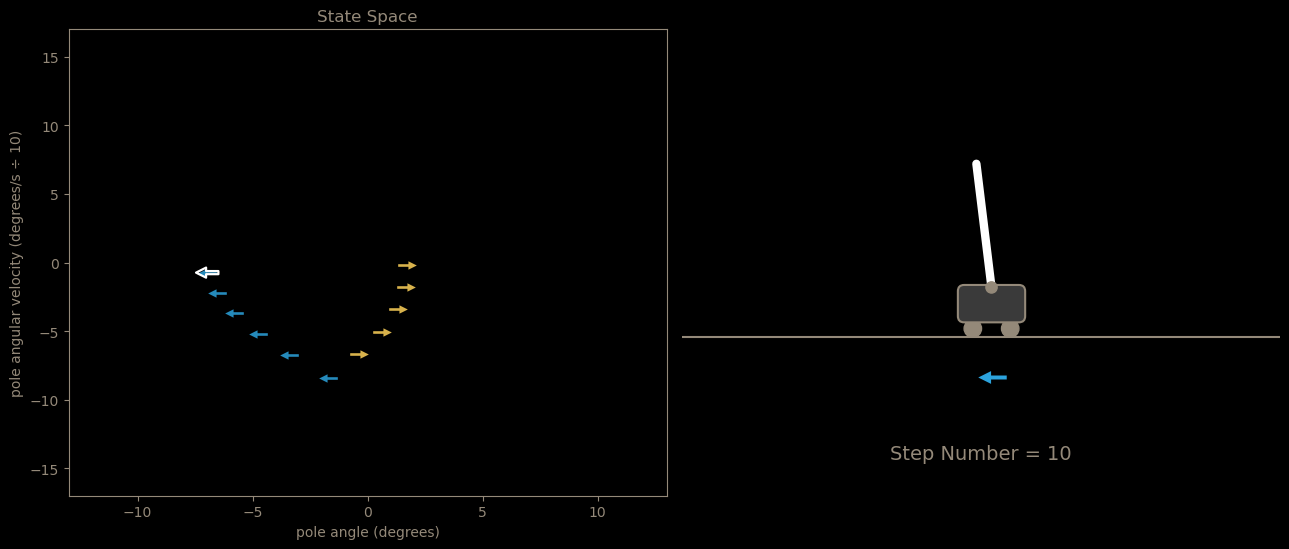

In [14]:
t=10
plt.clf()
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
axL.set_facecolor('k'); axR.set_facecolor('k')

ang    = np.degrees(obs[:, 2])
angvel = np.degrees(obs[:, 3])
m = act[:t+1] == 1
a, v = ang[:t+1], angvel[:t+1]
step_scatter_r=axL.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
step_scatter_l=axL.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)

is_terminal = (t == len(act)-1)
axL.scatter([ang[t]], [angvel[t]],
            marker=(RIGHT_ARROW if act[t]==1 else LEFT_ARROW), s=260,
            facecolors='none', edgecolors=(RED if is_terminal else 'w'),
            linewidths=1.6, zorder=5)

axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity (degrees/s \u00f7 10)')
axL.set_title('State Space'); style_ax(axL)

draw_cartpole(axR, obs[t,0], obs[t,2], action=act[t])
axR.text(0.5, -0.2, f'Step Number = {t}', transform=axR.transAxes,
         ha='center', va='bottom', color=CHILL_BROWN, fontsize=14)
plt.tight_layout()
# if save:
#     plt.savefig(save, dpi=140, facecolor='k'); plt.close(fig)
# step_scatter_r.set_alpha(0.3)
# step_scatter_l.set_alpha(0.3)

### Ok let's get an animation loop going

In [15]:
import os
from pathlib import Path

  0%|                                                                    | 0/18 [00:00<?, ?it/s]

0 60


  6%|███▎                                                        | 1/18 [00:12<03:28, 12.29s/it]

1 19
2 62


 11%|██████▋                                                     | 2/18 [00:23<03:04, 11.51s/it]


KeyboardInterrupt: 

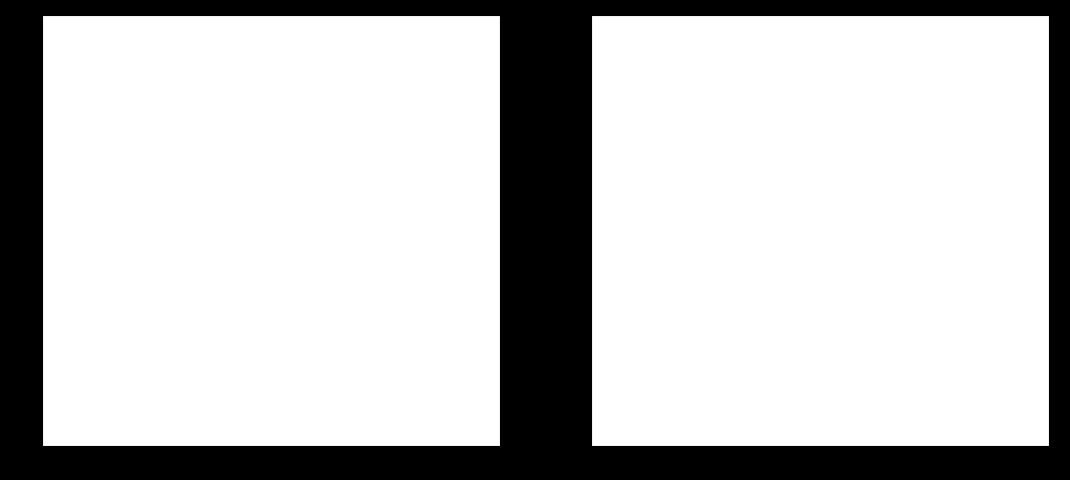

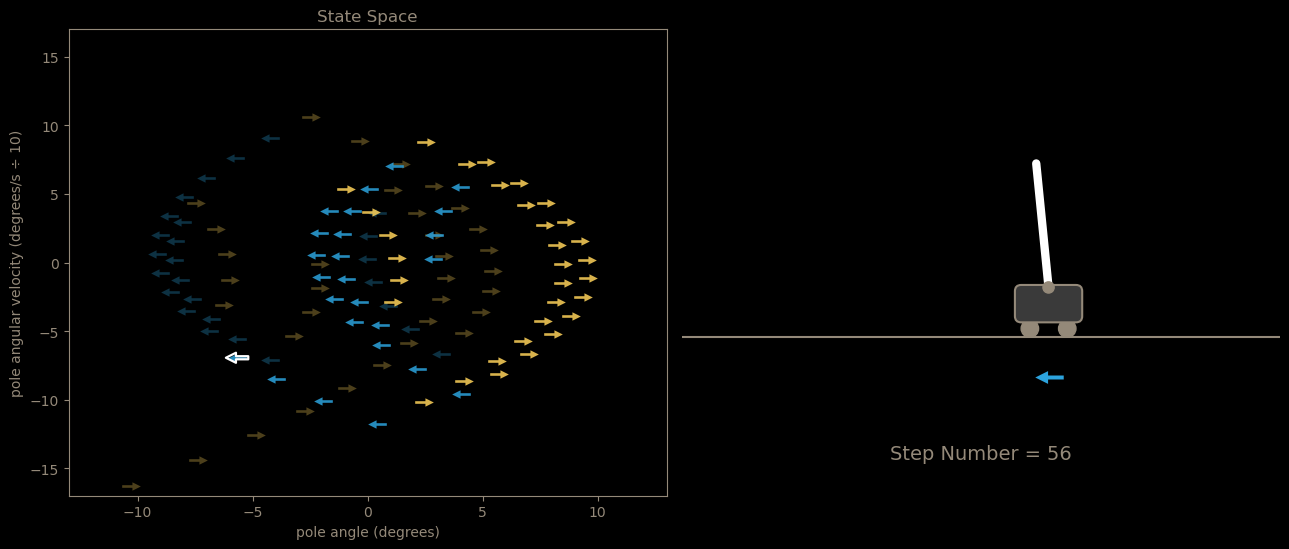

In [16]:
save_dir=Path(HACKIN_DIR+'/cart_pole_state_space_7')
os.makedirs(save_dir, exist_ok=True)

GLOBAL_COUNT=0
PERSIST_EPISODES=True
TERMINAL_HOLD=7
MIN_EPISODE_LEN=30
history=[]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
for episode_id in tqdm(range(len(data["episodes"]))):
    # os.makedirs(save_dir/str(episode_id), exist_ok=True) #Try one where they all go to the same folder
    
    all_obs=[]
    all_actions=[]
    episode_ids=[]
    
    for i in [episode_id]: 
        ep=data["episodes"][i]
        all_obs.append(ep["observations"])
        all_actions.append(ep["actions"])
        episode_ids.append(np.ones(len(ep["actions"]))*episode_id)
        # episode_id+=1
        print(i, len(ep['observations']))
    
    obs=np.concatenate(all_obs)
    act=np.concatenate(all_actions)
    ep_ids=np.concatenate(episode_ids)

    if len(act)<MIN_EPISODE_LEN: continue
    
    for t in range(len(obs)):
        # plt.clf()
        fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
        axL.set_facecolor('k'); axR.set_facecolor('k')

        if PERSIST_EPISODES:
            for h in history:
                axL.scatter(h['a'][h['m']],  h['v'][h['m']],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.3, linewidths=0)
                axL.scatter(h['a'][~h['m']], h['v'][~h['m']], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.3, linewidths=0)
        
        ang    = np.degrees(obs[:, 2])
        angvel = np.degrees(obs[:, 3])
        m = act[:t+1] == 1
        a, v = ang[:t+1], angvel[:t+1]
        axL.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
        axL.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)
        
        is_terminal = (t == len(act)-1)
        axL.scatter([ang[t]], [angvel[t]],
                    marker=(RIGHT_ARROW if act[t]==1 else LEFT_ARROW), s=260,
                    facecolors='none', edgecolors=(RED if is_terminal else 'w'),
                    linewidths=1.6, zorder=5)
        
        axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
        axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity (degrees/s \u00f7 10)')
        axL.set_title('State Space'); style_ax(axL)
        
        draw_cartpole(axR, obs[t,0], obs[t,2], action=act[t])
        axR.text(0.5, -0.2, f'Step Number = {t}', transform=axR.transAxes,
             ha='center', va='bottom', color=CHILL_BROWN, fontsize=14)
        plt.tight_layout()
        # plt.savefig(save_dir/str(episode_id)/(str(t).zfill(3)+'.png'), dpi=140, facecolor='k'); plt.close(fig)
        plt.savefig(save_dir/(str(GLOBAL_COUNT).zfill(3)+'.png'), dpi=240, facecolor='k'); 
        if is_terminal:
            for k in range(TERMINAL_HOLD):
                plt.savefig(save_dir/(str(GLOBAL_COUNT).zfill(3)+'.png'), dpi=240, facecolor='k'); 
                GLOBAL_COUNT+=1
        else:
            GLOBAL_COUNT+=1
        plt.close(fig)
        
    if PERSIST_EPISODES:
        history.append({'a':a, 'v':v, 'm':m})

#Final cumulative
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
axL.set_facecolor('k'); axR.set_facecolor('k')
for h in history:
    axL.scatter(h['a'][h['m']],  h['v'][h['m']],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
    axL.scatter(h['a'][~h['m']], h['v'][~h['m']], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)
    
axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity (degrees/s \u00f7 10)')
axL.set_title('State Space'); style_ax(axL)
plt.tight_layout()
plt.savefig(save_dir/(str(GLOBAL_COUNT).zfill(3)+'.png'), dpi=240, facecolor='k'); 

### 2. Visualize Data

In [12]:
class Pi(nn.Module):
    """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity.

    P(right) = sigmoid(logit). Returns [P(left), P(right)] with shape (2,) or (T, 2),
    so the REINFORCE loop below is unchanged from the neural net version.
    """
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

    def forward(self, x):
        feats = x[..., 2:4]                # state indices 2, 3: pole angle, pole angular velocity
        logit = feats @ self.theta         # scalar or (T,)
        p_right = torch.sigmoid(logit)
        return torch.stack([1.0 - p_right, p_right], dim=-1)

In [13]:
def scale_state(s):
    s = s.astype(np.float32).copy()
    s[1] /= VEL_SCALE; s[3] /= VEL_SCALE   # same /10 velocity scaling as the demo data
    return s

def run_rollout(seed, deterministic=False):
    # --- rollout: collect one episode ---
    states, actions, rewards = [], [], []
    state, _ = env.reset(seed=seed)
    state = scale_state(state)
    for t in range(500):                                # CartPole-v1 max timestep is 500
        with torch.no_grad():                           # no graph needed here; we recompute below
            probs = pi(torch.from_numpy(state))

        if deterministic:
            action=probs.argmax().item() #Armax instead of sample!
        else:
            action = np.random.choice(out_dim, p=probs.numpy())

        states.append(state)                            # note: stored states are velocity-scaled
        actions.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        state = scale_state(state)
        rewards.append(reward)
        if terminated or truncated:
            break

    return states, actions, rewards

In [14]:
# ---- losses ----
def ce_loss(probs, y):
    # cross-entropy on model-output probabilities: -log P(a_demo)
    p_taken = probs.gather(-1, y.unsqueeze(-1)).squeeze(-1)
    return -torch.log(p_taken.clamp_min(1e-8)).mean()

def l1_loss(probs, y):
    # L1 between predicted distribution and one-hot demo action
    onehot = nn.functional.one_hot(y, num_classes=2).float()
    return (probs - onehot).abs().sum(dim=-1).mean() #SW: A little clunky, do we really nead a sum and a mean?

In [15]:
with open("cartpole_human_play/cartpole_human_demos_sw_3.json") as f: #This one has some pretty good runs from SW
    data = json.load(f)

# with open("cartpole_human_play/cartpole_human_demos_pranav_4.json") as f: 
#     data = json.load(f) 

VEL_SCALE = 10   # divide all velocities by 10 -> feature scales comparable, ~isotropic parameter space
for ep in data["episodes"]:
    o = np.array(ep["observations"], dtype=np.float64)
    o[:, 1] /= VEL_SCALE   # cart velocity
    o[:, 3] /= VEL_SCALE   # pole angular velocity
    ep["observations"] = o

print(len(data["episodes"]))

18


In [16]:
# for i, ep in enumerate(data['episodes']):
#     print(i, len(ep["actions"]))

In [17]:
# for ep_id in range(len(ep["actions"])):
#     all_obs=[]
#     all_actions=[]
#     episode_ids=[]

#     for i in [ep_id]: 
#         ep=data["episodes"][i]
#         all_obs.append(ep["observations"])
#         all_actions.append(ep["actions"])
#         episode_ids.append(np.ones(len(ep["actions"]))*episode_id)
#         episode_id+=1
#         # print(i, len(ep['observations']))

#     obs=np.concatenate(all_obs)
#     act=np.concatenate(all_actions)
#     ep_ids=np.concatenate(episode_ids)

#     X = torch.tensor(obs, dtype=torch.float32)   # (N, 4) — Pi slices out dims 2:4 itself
#     y = torch.tensor(act, dtype=torch.long)      # (N,)  values in {0, 1}

#     seed=52
#     lr=0.1
#     steps=50000
    
#     torch.manual_seed(seed)
#     pi = Pi()
#     opt = torch.optim.SGD(pi.parameters(), lr=lr)   # plain SGD: trajectory = gradient flow on the surface
#     loss_fn = l1_loss
    
#     traj = [pi.theta.detach().clone().numpy()]      # parameter path for the 2D plot
#     losses = []
    
#     for step in range(steps):
#         probs = pi(X)                                # (N, 2), full batch
#         loss = loss_fn(probs, y)
#         opt.zero_grad()
#         loss.backward()
#         opt.step()
    
#         traj.append(pi.theta.detach().clone().numpy())
#         losses.append(loss.item())
#         if step % 5000 == 0 or step == steps - 1:
#             acc = (probs.argmax(-1) == y).float().mean().item()
#             # print(f"[ step {step:4d}  loss {loss.item():.4f}  acc {acc:.3f}  "
#             #       f"theta = ({pi.theta[0].item():+.3f}, {pi.theta[1].item():+.3f})")

#     env = gym.make("CartPole-v1")
#     out_dim = env.action_space.n 
    
#     rewardz=[]
#     for i in range(128):
#         states, actions, rewards=run_rollout(seed=i, deterministic=True)
#         rewardz.append(np.sum(rewards))
#     # plt.figure(0, (5,2))
#     # plt.hist(rewardz, 20);
#     # plt.title(np.mean(rewardz))
#     print(ep_id, len(ep["actions"]), np.mean(rewardz))

In [18]:
all_obs=[]
all_actions=[]
episode_ids=[]

# num_training_episodes=100
# min_episode_len=30
# episode_id=0

# for i, ep in enumerate(data["episodes"]):
#     if len(ep['observations'])>min_episode_len:
#         all_obs.append(ep["observations"])
#         all_actions.append(ep["actions"])
#         episode_ids.append(np.ones(len(ep["actions"]))*episode_id)
#         episode_id+=1
#         print(i, len(ep['observations']))
#     if episode_id==(num_training_episodes):
#         break

#sw_3
#6 restults in an average run of 23, some nice spread
# 13 alone is kinda nice, average run is 70
# 0, 13 from cartpole_human_demos_sw_3 gets middling but not collapsed determnistic performance, 23 average

#cartpole_human_demos_pranav_4
#ep 55 runs for 195 steps, average return is 143.9

for i in [13]: 
    ep=data["episodes"][i]
    all_obs.append(ep["observations"])
    all_actions.append(ep["actions"])
    episode_ids.append(np.ones(len(ep["actions"]))*episode_id)
    episode_id+=1
    print(i, len(ep['observations']))

obs=np.concatenate(all_obs)
act=np.concatenate(all_actions)
ep_ids=np.concatenate(episode_ids)

13 66


In [19]:
len(obs)

66

In [20]:
X = torch.tensor(obs, dtype=torch.float32)   # (N, 4) — Pi slices out dims 2:4 itself
y = torch.tensor(act, dtype=torch.long)      # (N,)  values in {0, 1}

In [21]:
obs.shape, act.shape, ep_ids.shape

((66, 4), (66,), (66,))

<Figure size 640x480 with 0 Axes>

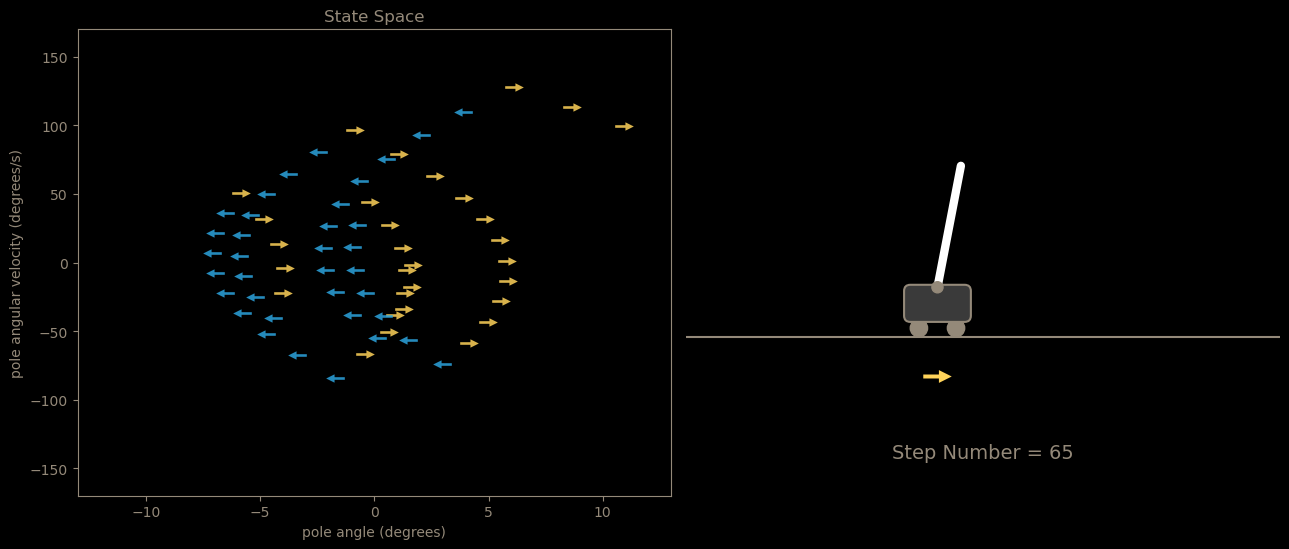

In [22]:
t=len(obs)-1
plt.clf()
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
axL.set_facecolor('k'); axR.set_facecolor('k')

ang    = np.degrees(obs[:, 2])
angvel = np.degrees(obs[:, 3])
m = act[:t+1] == 1
a, v = ang[:t+1], angvel[:t+1]
step_scatter_r=axL.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
step_scatter_l=axL.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)

# is_terminal = (t == len(act)-1)
# axL.scatter([ang[t]], [angvel[t]],
#             marker=(RIGHT_ARROW if act[t]==1 else LEFT_ARROW), s=260,
#             facecolors='none', edgecolors=(RED if is_terminal else 'w'),
#             linewidths=1.6, zorder=5)

axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity (degrees/s \u00f7 10)')
axL.set_title('State Space'); style_ax(axL)

draw_cartpole(axR, obs[t,0], obs[t,2], action=act[t])
axR.text(0.5, -0.2, f'Step Number = {t}', transform=axR.transAxes,
         ha='center', va='bottom', color=CHILL_BROWN, fontsize=14)
plt.tight_layout()

plt.savefig('sw_ep_13_2.png', dpi=240, facecolor='k'); #plt.close(fig)

## 3. Visualize walk through parameter space

In [23]:
# same constants as the manim scenes
SWEEP_T1_RANGE = (-2.0, 2.0)
SWEEP_T2_RANGE = (-1.0, 1.0)  # x10 to match the /10 velocity scaling -- NOTE: manim scenes need the same update!
SWEEP_TIME = 4          # seconds, for each of the two straight sweeps
TRANSITION_TIME = 1.5   # seconds, for the two "get into position" moves
ELLIPSE_TIME = 6        # seconds, for the full loop around parameter space


def manim_smooth(t, inflection=10.0):
    """Reproduces manimgl's default `smooth` rate_func (sigmoid-based
    ease-in/ease-out), so the transition legs match the manim scenes."""
    t = np.clip(t, 0, 1)
    error = 1 / (1 + np.exp(inflection / 2))
    raw = 1 / (1 + np.exp(-inflection * (t - 0.5)))
    return np.clip((raw - error) / (1 - 2 * error), 0, 1)


def generate_theta_sweep(fps=30):
    """
    Returns an (N, 2) array of (theta1, theta2) samples, one row per frame,
    following the same choreography as play_theta_sweep() in the manim
    scenes:
      1. sweep theta1, -2 -> 2, theta2 held at 0             (SWEEP_TIME, linear)
      2. transition to theta2 sweep's start, (0, -1.0)       (TRANSITION_TIME, smooth)
      3. sweep theta2, -1 -> 1, theta1 held at 0         (SWEEP_TIME, linear)
      4. transition to the ellipse's start, (2, 0)           (TRANSITION_TIME, smooth)
      5. one full loop around the ellipse                    (ELLIPSE_TIME, linear in angle)
    """
    t1_lo, t1_hi = SWEEP_T1_RANGE
    t2_lo, t2_hi = SWEEP_T2_RANGE

    def n_frames(duration):
        return max(int(round(duration * fps)), 2)

    segments = []

    # 1. sweep theta1, theta2 fixed at 0
    n = n_frames(SWEEP_TIME)
    a = np.linspace(0, 1, n)
    segments.append(np.stack([t1_lo + a * (t1_hi - t1_lo), np.zeros(n)], axis=1))

    # 2. transition to (0, t2_lo)
    n = n_frames(TRANSITION_TIME)
    a = manim_smooth(np.linspace(0, 1, n))
    segments.append(np.stack([t1_hi + a * (0 - t1_hi), 0 + a * (t2_lo - 0)], axis=1))

    # 3. sweep theta2, theta1 fixed at 0
    n = n_frames(SWEEP_TIME)
    a = np.linspace(0, 1, n)
    segments.append(np.stack([np.zeros(n), t2_lo + a * (t2_hi - t2_lo)], axis=1))

    # 4. transition to ellipse start, (t1_hi, 0)
    n = n_frames(TRANSITION_TIME)
    a = manim_smooth(np.linspace(0, 1, n))
    segments.append(np.stack([0 + a * (t1_hi - 0), t2_hi + a * (0 - t2_hi)], axis=1))

    
    c1, r1 = (t1_lo + t1_hi) / 2, (t1_hi - t1_lo) / 2   # 0.2, 0.4
    c2, r2 = (t2_lo + t2_hi) / 2, (t2_hi - t2_lo) / 2   # 0.0, 0.15
    # 5. one full loop around the ellipse inscribed in the sweep ranges
    n = n_frames(ELLIPSE_TIME)
    theta = np.linspace(0, 2 * np.pi, n)
    segments.append(np.stack([c1 + r1 * np.cos(theta),
                              c2 + r2 * np.sin(theta)], axis=1))

    return np.concatenate(segments, axis=0)

In [24]:
all_obs=[]
all_actions=[]
episode_ids=[]

for i in [13]: 
    ep=data["episodes"][i]
    all_obs.append(ep["observations"])
    all_actions.append(ep["actions"])
    episode_ids.append(np.ones(len(ep["actions"]))*episode_id)
    episode_id+=1
    print(i, len(ep['observations']))

obs=np.concatenate(all_obs)
act=np.concatenate(all_actions)
ep_ids=np.concatenate(episode_ids)

save_dir=Path(HACKIN_DIR+'/parameter_space_walk_2')
os.makedirs(save_dir, exist_ok=True)

13 66


In [25]:
# thetas=generate_theta_sweep()

# for step_num in tqdm(range(len(thetas))): 
    
#     t1=thetas[step_num][0].item()
#     t2=thetas[step_num][1].item()
    
#     t=len(obs)-1
#     plt.clf()
#     fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
#     axL.set_facecolor('k'); axR.set_facecolor('k')
    
#     A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
#     P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
#     im = axL.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
#                     extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
#     axL.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
    
#     ang    = np.degrees(obs[:, 2])
#     angvel = np.degrees(obs[:, 3])
#     m = act[:t+1] == 1
#     a, v = ang[:t+1], angvel[:t+1]
#     step_scatter_r=axL.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
#     step_scatter_l=axL.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)
    
    
#     axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
#     axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity (degrees/s \u00f7 10)')
#     axL.set_title('State Space'); style_ax(axL)
    
#     axR.scatter(t1, t2, c='g', s=75)
    
#     axR.set_xlim(-2.2, 2.2)
#     axR.set_ylim(-1.2, 1.2)
#     axR.set_xlabel(r'$\theta_1$ (pole angle weight)')
#     axR.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
#     axR.set_title('Parameter Space'); style_ax(axR)
#     # axR.grid(1)
    
#     plt.tight_layout()
    
#     plt.savefig(save_dir/('parameter_space_walk_'+str(step_num).zfill(3)+'.png'), dpi=240, facecolor='k'); 
#     plt.close(fig)

## 4. Visualize Loss Landscape

In [26]:
# np.degrees(10)
X_Degrees=np.degrees(X)

/var/folders/j5/ks68pdf144xgrs0s77q51qxw0000gn/T/ipykernel_12640/2167788256.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_Degrees=np.degrees(X)


In [27]:
# X[0, -1]*180/np.pi

In [28]:
# X_Degrees

100%|██████████████████████| 128/128 [00:00<00:00, 289.88it/s]


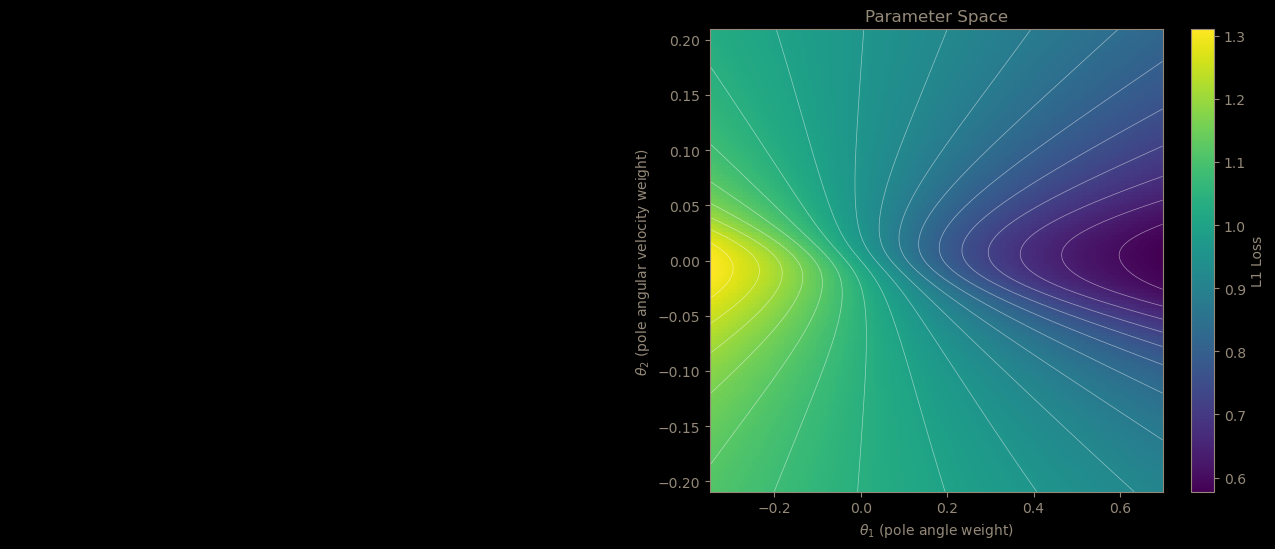

In [29]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
axL.set_facecolor('k'); axR.set_facecolor('k')

theta1_vals_viz = np.linspace(-20, 40, 128)
theta2_vals_viz = np.linspace(-30, 30, 128)   # span matches theta1 -> square extent

pi_probe = Pi()
L_vals = np.zeros((len(theta1_vals_viz), len(theta2_vals_viz)))

with torch.no_grad():
    for i, t1v in enumerate(tqdm(theta1_vals_viz)):
        for j, t2v in enumerate(theta2_vals_viz):
            pi_probe.theta[:] = torch.tensor([t1v, t2v])     # place the model at this theta
            L_vals[i, j] = l1_loss(pi_probe(X), y)         # same loss, same data as training

extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
im = axR.imshow(L_vals.T, origin='lower', cmap='viridis',   # reversed: bright = low loss
                #Something feels kinda fishy about this, makes sense on paper, but worried I'm missing something
                # For a couple different reasons I think it makes sense to keep actually running the game in radians, 
                # but reporting the game in degrees. So my x/y get converged to degrees before reporting, which I'm 
                # pretty sure means that my parameters need to be converted the other way before reporting. 
                # Could be good to sanity check before we ship the final video
                extent=np.radians(extent), 
                aspect='equal')   # square, isotropic parameter space
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = axR.contour(T1, T2, L_vals.T, levels=20,
                 colors='w', linewidths=0.5, alpha=0.5)

# axR.set_xlim(-2.2, 2.2)
# axR.set_ylim(-0.12, 0.12)
axR.set_xlabel(r'$\theta_1$ (pole angle weight)')
axR.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
axR.set_title('Parameter Space'); style_ax(axR)

cb = fig.colorbar(im, ax=axR)
cb.set_label('L1 Loss', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)

plt.tight_layout()
plt.savefig('loss_landscape_2.png', dpi=240, facecolor='k'); 

## 5. Visualize Gradient Direction!

In [30]:
save_dir=Path(HACKIN_DIR+'/gradient_direction_sweep_3')
os.makedirs(save_dir, exist_ok=True)

In [31]:
def loss_and_grad_deg(t1_deg, t2_deg):
    t1_rad, t2_rad = np.degrees([t1_deg, t2_deg])
    logit = t1_rad * ang_rad + t2_rad * angvel_rad
    p = 1.0 / (1.0 + np.exp(-logit))
    diff = p - act
    loss = 2.0 * np.mean(np.abs(diff))          # matches l1_loss exactly
    dp = p * (1.0 - p)
    grad_rad = np.array([
        2.0 * np.mean(np.sign(diff) * dp * ang_rad),
        2.0 * np.mean(np.sign(diff) * dp * angvel_rad),
    ])
    return loss, np.degrees(grad_rad)

100%|██████████████████████| 128/128 [00:00<00:00, 298.09it/s]


Text(0.5058823529411764, 0.0, '')

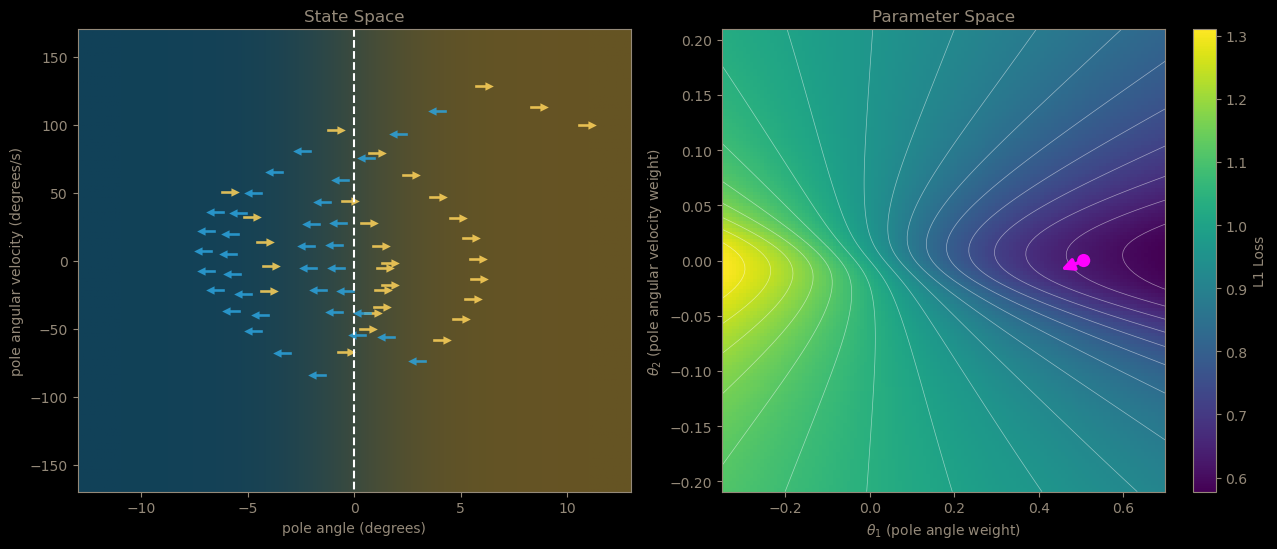

In [32]:
# SWEEP_T1_RANGE = (-2.0, 2.0)
# SWEEP_T2_RANGE = (-1.0, 1.0)

SWEEP_T1_RANGE = (-0.2, 0.6)
SWEEP_T2_RANGE = (-1.5, 1.5)

thetas=generate_theta_sweep()

theta1_vals_viz = np.linspace(-20, 40, 128)
theta2_vals_viz = np.linspace(-30, 30, 128)   # span matches theta1 -> square extent

pi_probe = Pi()
L_vals = np.zeros((len(theta1_vals_viz), len(theta2_vals_viz)))

with torch.no_grad():
    for i, t1v in enumerate(tqdm(theta1_vals_viz)):
        for j, t2v in enumerate(theta2_vals_viz):
            pi_probe.theta[:] = torch.tensor([t1v, t2v])     # place the model at this theta
            L_vals[i, j] = l1_loss(pi_probe(X), y)         # same loss, same data as training


ang_rad, angvel_rad = obs[:, 2], obs[:, 3]   # radians; angvel pre-divided by VEL_SCALE -- exactly what the model (X) sees


step_num=105
viz_scale=0.08
min_draw_len=0.06
max_draw_len=0.12
# max_draw_len=

t1=thetas[step_num][0].item()
t2=thetas[step_num][1].item()

# t1=-0.2
# t2=-0.05

loss_here, grad_deg = loss_and_grad_deg(t1, t2)


fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
axL.set_facecolor('k'); axR.set_facecolor('k')

# ---- left: state space at the current theta ----
A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
axL.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
           extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
axL.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

m = act == 1
axL.scatter(ang[m], angvel[m], marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
axL.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW, s=180, color=BLUE, alpha=0.85, linewidths=0)

axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity (degrees/s \u00f7 10)')
axL.set_title('State Space'); style_ax(axL)



extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
im = axR.imshow(L_vals.T, origin='lower', cmap='viridis',   # reversed: bright = low loss
                #Something feels kinda fishy about this, makes sense on paper, but worried I'm missing something
                # For a couple different reasons I think it makes sense to keep actually running the game in radians, 
                # but reporting the game in degrees. So my x/y get converged to degrees before reporting, which I'm 
                # pretty sure means that my parameters need to be converted the other way before reporting. 
                # Could be good to sanity check before we ship the final video
                extent=np.radians(extent), 
                aspect='equal')   # square, isotropic parameter space
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = axR.contour(T1, T2, L_vals.T, levels=20,
                 colors='w', linewidths=0.5, alpha=0.5)


# axR.scatter([t1], [t2], s=90, color='magenta', zorder=5, edgecolors='none')
# axR.annotate('', xy=(t1 + viz_scale*grad_deg[0], t2 + viz_scale*grad_deg[1]), xytext=(t1, t2),
#                  arrowprops=dict(arrowstyle='-|>', color='magenta', lw=2.5, mutation_scale=18))


# axR.set_xlim(-2.2, 2.2)
# axR.set_ylim(-0.12, 0.12)
# axR.set_xlim(*SWEEP_T1_RANGE); axR.set_ylim(*SWEEP_T2_RANGE)
axR.set_xlabel(r'$\theta_1$ (pole angle weight)')
axR.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
axR.set_title('Parameter Space'); style_ax(axR)

cb = fig.colorbar(im, ax=axR)
cb.set_label('L1 Loss', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)

plt.tight_layout()


# velocities are pre-scaled by 1/10 and the panel uses aspect='equal', so the plain
# data-coord gradient is also perpendicular to the contours on screen -- no correction needed
u = grad_deg / np.linalg.norm(grad_deg)
g_draw = u * np.clip(viz_scale * np.linalg.norm(grad_deg), min_draw_len, max_draw_len)
axR.scatter([t1], [t2], s=90, color='magenta', zorder=5, edgecolors='none')
axR.annotate('', xy=(t1 + g_draw[0], t2 +g_draw[1]), xytext=(t1, t2),
                 arrowprops=dict(arrowstyle='-|>', color='magenta', lw=2.5, mutation_scale=18))


# plt.savefig(save_dir/('gradient_direction_sweep_'+str(step_num).zfill(3)+'.png'), dpi=240, facecolor='k'); 

In [33]:
np.linalg.norm(g_draw)

np.float64(0.06)

### Now Loop Version!

In [34]:
# SWEEP_T1_RANGE = (-2.0, 2.0)
# SWEEP_T2_RANGE = (-1.0, 1.0)

SWEEP_T1_RANGE = (-0.2, 0.6)
SWEEP_T2_RANGE = (-1.5, 1.5)
viz_scale=0.08
min_draw_len=0.06
max_draw_len=0.12

thetas=generate_theta_sweep()

theta1_vals_viz = np.linspace(-20, 40, 128)
theta2_vals_viz = np.linspace(-30, 30, 128)   # span matches theta1 -> square extent

pi_probe = Pi()
L_vals = np.zeros((len(theta1_vals_viz), len(theta2_vals_viz)))

with torch.no_grad():
    for i, t1v in enumerate(tqdm(theta1_vals_viz)):
        for j, t2v in enumerate(theta2_vals_viz):
            pi_probe.theta[:] = torch.tensor([t1v, t2v])     # place the model at this theta
            L_vals[i, j] = l1_loss(pi_probe(X), y)         # same loss, same data as training


ang_rad, angvel_rad = obs[:, 2], obs[:, 3]   # radians; angvel pre-divided by VEL_SCALE -- exactly what the model (X) sees


for step_num in tqdm(range(len(thetas))):

    t1=thetas[step_num][0].item()
    t2=thetas[step_num][1].item()
    
    # t1=-0.2
    # t2=-0.05
    
    loss_here, grad_deg = loss_and_grad_deg(t1, t2)
    
    
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
    axL.set_facecolor('k'); axR.set_facecolor('k')
    
    # ---- left: state space at the current theta ----
    A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
    P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
    axL.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
               extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    axL.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
    
    m = act == 1
    axL.scatter(ang[m], angvel[m], marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
    axL.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW, s=180, color=BLUE, alpha=0.85, linewidths=0)
    
    axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
    axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity (degrees/s \u00f7 10)')
    axL.set_title('State Space'); style_ax(axL)
    
    
    
    extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
    im = axR.imshow(L_vals.T, origin='lower', cmap='viridis',   # reversed: bright = low loss
                    #Something feels kinda fishy about this, makes sense on paper, but worried I'm missing something
                    # For a couple different reasons I think it makes sense to keep actually running the game in radians, 
                    # but reporting the game in degrees. So my x/y get converged to degrees before reporting, which I'm 
                    # pretty sure means that my parameters need to be converted the other way before reporting. 
                    # Could be good to sanity check before we ship the final video
                    extent=np.radians(extent), 
                    aspect='equal')   # square, isotropic parameter space
    T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
    cs = axR.contour(T1, T2, L_vals.T, levels=20,
                     colors='w', linewidths=0.5, alpha=0.5)
    
    
    # axR.scatter([t1], [t2], s=90, color='magenta', zorder=5, edgecolors='none')
    # axR.annotate('', xy=(t1 + viz_scale*grad_deg[0], t2 + viz_scale*grad_deg[1]), xytext=(t1, t2),
    #                  arrowprops=dict(arrowstyle='-|>', color='magenta', lw=2.5, mutation_scale=18))
    
    
    # axR.set_xlim(-2.2, 2.2)
    # axR.set_ylim(-0.12, 0.12)
    # axR.set_xlim(*SWEEP_T1_RANGE); axR.set_ylim(*SWEEP_T2_RANGE)
    axR.set_xlabel(r'$\theta_1$ (pole angle weight)')
    axR.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
    axR.set_title('Parameter Space'); style_ax(axR)
    
    cb = fig.colorbar(im, ax=axR)
    cb.set_label('L1 Loss', color=CHILL_BROWN)
    cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
    plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
    cb.outline.set_edgecolor(CHILL_BROWN)
    
    plt.tight_layout()
    
    
    grad_deg*=-1 #Ok i think i want to do negative grad here actually!
    # isotropic + aspect='equal' -> plain data-coord arrow, no screen-space correction
    u = grad_deg / np.linalg.norm(grad_deg)
    g_draw = u * np.clip(viz_scale * np.linalg.norm(grad_deg), min_draw_len, max_draw_len)
    axR.scatter([t1], [t2], s=90, color='magenta', zorder=5, edgecolors='none')
    axR.annotate('', xy=(t1 + g_draw[0], t2 +g_draw[1]), xytext=(t1, t2),
                     arrowprops=dict(arrowstyle='-|>', color='magenta', lw=2.5, mutation_scale=18))
    
    plt.savefig(save_dir/('gradient_direction_sweep_'+str(step_num).zfill(3)+'.png'), dpi=240, facecolor='k'); 
    plt.close(fig)

100%|███████████████████████| 510/510 [03:24<00:00,  2.50it/s]


## 6. Visualize Learning Process

Two panels again, visualizing training process. Instrument the loop below, and then visualize. Plot path through parameter space using a magenta line, and include the gradient direction arrow using the same approach as above!

In [60]:
seed=52
lr=0.1
steps=50000

torch.manual_seed(seed)
pi = Pi()

with torch.no_grad(): #Crappier starting poing?
    pi.theta=nn.Parameter(torch.tensor([np.degrees(-0.2), np.degrees(-0.5)]).float())  # theta2 x10: same point as before in rescaled units

opt = torch.optim.SGD(pi.parameters(), lr=lr)   # plain SGD: trajectory = gradient flow on the surface
loss_fn = l1_loss

traj = [pi.theta.detach().clone().numpy()]      # parameter path for the 2D plot
losses = []

for step in range(steps):
    probs = pi(X)                                # (N, 2), full batch
    loss = loss_fn(probs, y)
    opt.zero_grad()
    loss.backward()
    opt.step()

    traj.append(pi.theta.detach().clone().numpy())
    losses.append(loss.item())
    if step % 5000 == 0 or step == steps - 1:
        acc = (probs.argmax(-1) == y).float().mean().item()
        print(f"[ step {step:4d}  loss {loss.item():.4f}  acc {acc:.3f}  "
              f"theta = ({pi.theta[0].item():+.3f}, {pi.theta[1].item():+.3f})")

[ step    0  loss 1.1750  acc 0.394  theta = (-11.458, -2.867)
[ step 5000  loss 1.0825  acc 0.455  theta = (-8.122, -8.268)
[ step 10000  loss 1.0638  acc 0.485  theta = (-5.837, -10.260)
[ step 15000  loss 1.0533  acc 0.485  theta = (-3.860, -11.424)
[ step 20000  loss 1.0456  acc 0.485  theta = (-2.049, -12.158)
[ step 25000  loss 1.0394  acc 0.485  theta = (-0.341, -12.594)
[ step 30000  loss 1.0338  acc 0.485  theta = (+1.309, -12.788)
[ step 35000  loss 1.0285  acc 0.500  theta = (+2.935, -12.761)
[ step 40000  loss 1.0231  acc 0.500  theta = (+4.571, -12.509)
[ step 45000  loss 1.0169  acc 0.500  theta = (+6.252, -12.005)
[ step 49999  loss 1.0092  acc 0.500  theta = (+8.023, -11.184)


Text(0.5, 1.0, '9.5703125')

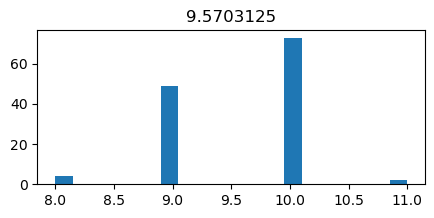

In [61]:
env = gym.make("CartPole-v1")
out_dim = env.action_space.n 

rewardz=[]
for i in range(128):
    states, actions, rewards=run_rollout(seed=i, deterministic=True)
    rewardz.append(np.sum(rewards))
plt.figure(0, (5,2))
plt.hist(rewardz, 20);
plt.title(np.mean(rewardz))

In [62]:
# ---- precompute: loss landscape + training path in plot coordinates ----
theta1_vals_viz = np.linspace(-20, 40, 128)
theta2_vals_viz = np.linspace(-30, 30, 128)   # span matches theta1 -> square extent

pi_probe = Pi()
L_vals = np.zeros((len(theta1_vals_viz), len(theta2_vals_viz)))

with torch.no_grad():
    for i, t1v in enumerate(tqdm(theta1_vals_viz)):
        for j, t2v in enumerate(theta2_vals_viz):
            pi_probe.theta[:] = torch.tensor([t1v, t2v])     # place the model at this theta
            L_vals[i, j] = l1_loss(pi_probe(X), y)           # same loss, same data as training

ang_rad, angvel_rad = obs[:, 2], obs[:, 3]   # radians; angvel pre-divided by VEL_SCALE -- exactly what the model (X) sees
ang, angvel = np.degrees(obs[:, 2]), np.degrees(obs[:, 3])

# traj is in the model's native per-radian units; the parameter space axes report
# per-degree weights (same convention as the landscape extent) -> np.radians() converts
traj_arr = np.array(traj)          # (steps+1, 2)
traj_plot = np.radians(traj_arr)

# 50k steps is way too many frames -- log-space the step indices since most of the action is early
n_frames = 150
frame_steps = np.unique(np.concatenate([[0], np.geomspace(1, len(traj_arr)-1, n_frames-1).astype(int)]))
print(len(frame_steps), 'frames |  theta path start', traj_plot[0], ' end', traj_plot[-1])

100%|██████████████████████| 128/128 [00:00<00:00, 298.34it/s]

126 frames |  theta path start [-0.2  -0.05]  end [ 0.14002658 -0.19520135]


Text(-0.11664644628763199, -0.16790391504764557, '')

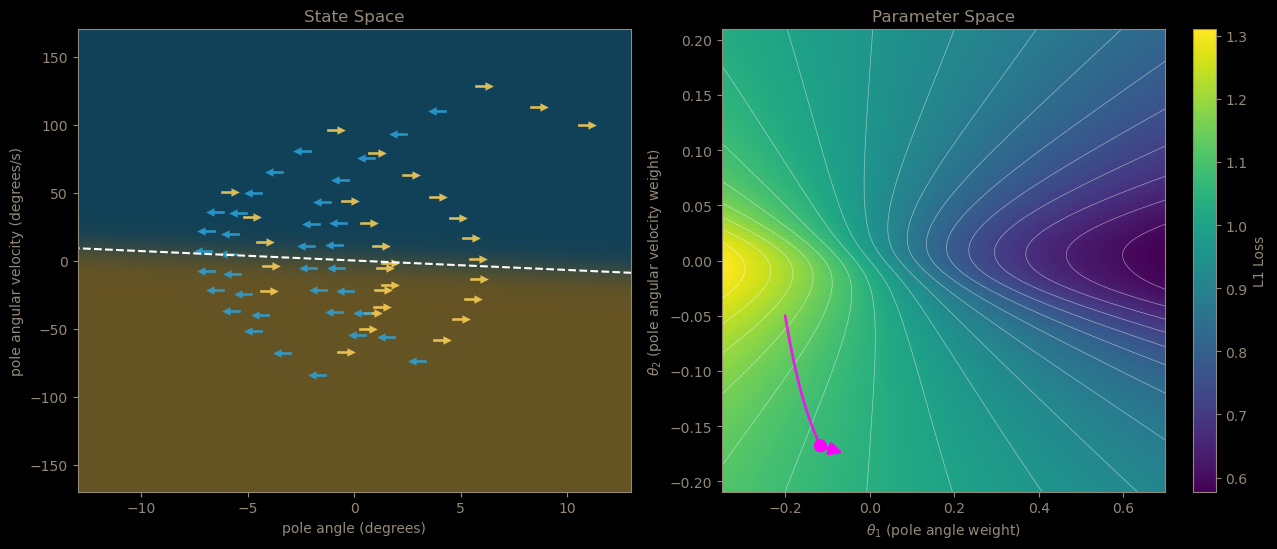

In [65]:
step_num = frame_steps[100]    # poke around different points along training
viz_scale=0.08
min_draw_len=0.06
max_draw_len=0.12

t1, t2 = traj_plot[step_num]
loss_here, grad_deg = loss_and_grad_deg(t1, t2)
grad_deg *= -1   # descent direction

# sanity check: the path step direction should be parallel to the descent direction
if 0 < step_num < len(traj_plot)-1:
    fd = traj_plot[step_num+1] - traj_plot[step_num-1]
    cos = fd @ grad_deg / (np.linalg.norm(fd)*np.linalg.norm(grad_deg) + 1e-12)
    print(f'cosine(path step, descent dir) = {cos:+.4f}')   # should be ~ +1.0

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
axL.set_facecolor('k'); axR.set_facecolor('k')

# ---- left: state space at the current theta ----
A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
axL.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
           extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
axL.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

m = act == 1
axL.scatter(ang[m], angvel[m], marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
axL.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW, s=180, color=BLUE, alpha=0.85, linewidths=0)

axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity (degrees/s \u00f7 10)')
axL.set_title('State Space'); style_ax(axL)

# ---- right: loss landscape + training path ----
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
im = axR.imshow(L_vals.T, origin='lower', cmap='viridis',
                extent=np.radians(extent),
                aspect='equal')   # square, isotropic parameter space
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = axR.contour(T1, T2, L_vals.T, levels=20,
                 colors='w', linewidths=0.5, alpha=0.5)

# path so far
axR.plot(traj_plot[:step_num+1, 0], traj_plot[:step_num+1, 1],
         color='magenta', lw=2.0, alpha=0.85, zorder=4, solid_capstyle='round')

axR.set_xlabel(r'$\theta_1$ (pole angle weight)')
axR.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
axR.set_title('Parameter Space'); style_ax(axR)

cb = fig.colorbar(im, ax=axR)
cb.set_label('L1 Loss', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)

plt.tight_layout()

# arrow along the true descent direction (tangent to the path); with the /10 velocity
# scaling + aspect='equal' this is also perpendicular to the contours on screen
u = grad_deg / np.linalg.norm(grad_deg)
g_draw = u * np.clip(viz_scale * np.linalg.norm(grad_deg), min_draw_len, max_draw_len)
axR.scatter([t1], [t2], s=90, color='magenta', zorder=5, edgecolors='none')
axR.annotate('', xy=(t1 + g_draw[0], t2 + g_draw[1]), xytext=(t1, t2),
                 arrowprops=dict(arrowstyle='-|>', color='magenta', lw=2.5, mutation_scale=18))

In [66]:
save_dir=Path(HACKIN_DIR+'/learning_process_2')
os.makedirs(save_dir, exist_ok=True)

In [ ]:
viz_scale=0.08
min_draw_len=0.06
max_draw_len=0.12

for frame_idx, step_num in enumerate(tqdm(frame_steps)):

    t1, t2 = traj_plot[step_num]
    loss_here, grad_deg = loss_and_grad_deg(t1, t2)
    grad_deg *= -1   # descent direction

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
    axL.set_facecolor('k'); axR.set_facecolor('k')

    # ---- left: state space at the current theta ----
    A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
    P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
    axL.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
               extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    axL.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

    m = act == 1
    axL.scatter(ang[m], angvel[m], marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
    axL.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW, s=180, color=BLUE, alpha=0.85, linewidths=0)

    axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
    axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity (degrees/s \u00f7 10)')
    axL.set_title('State Space'); style_ax(axL)

    # ---- right: loss landscape + training path ----
    extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
    im = axR.imshow(L_vals.T, origin='lower', cmap='viridis',
                    extent=np.radians(extent),
                    aspect='equal')   # square, isotropic parameter space
    T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
    cs = axR.contour(T1, T2, L_vals.T, levels=20,
                     colors='w', linewidths=0.5, alpha=0.5)

    axR.plot(traj_plot[:step_num+1, 0], traj_plot[:step_num+1, 1],
             color='magenta', lw=2.0, alpha=0.85, zorder=4, solid_capstyle='round')

    axR.set_xlabel(r'$\theta_1$ (pole angle weight)')
    axR.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
    axR.set_title('Parameter Space'); style_ax(axR)

    cb = fig.colorbar(im, ax=axR)
    cb.set_label('L1 Loss', color=CHILL_BROWN)
    cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
    plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
    cb.outline.set_edgecolor(CHILL_BROWN)

    plt.tight_layout()

    # arrow along the true descent direction; isotropic + equal aspect -> also contour-perpendicular
    u = grad_deg / np.linalg.norm(grad_deg)
    g_draw = u * np.clip(viz_scale * np.linalg.norm(grad_deg), min_draw_len, max_draw_len)
    axR.scatter([t1], [t2], s=90, color='magenta', zorder=5, edgecolors='none')
    axR.annotate('', xy=(t1 + g_draw[0], t2 + g_draw[1]), xytext=(t1, t2),
                     arrowprops=dict(arrowstyle='-|>', color='magenta', lw=2.5, mutation_scale=18))

    plt.savefig(save_dir/('learning_process_'+str(frame_idx).zfill(3)+'.png'), dpi=240, facecolor='k')
    plt.close(fig)

 12%|██▊                     | 15/126 [00:06<00:46,  2.37it/s]